# Decision Tree
Using the Supervised Learning Algorithm

## Import library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
%matplotlib inline

## Load dataset

In [3]:
path_folder = '../Dataset/wine_quality'
os.path.exists(path_folder)

True

In [4]:
df_red = pd.read_csv(os.path.join(path_folder, 'winequality-red.csv'), sep=';', quotechar='"')
df_white = pd.read_csv(os.path.join(path_folder, 'winequality-white.csv'), sep=';', quotechar='"')

In [5]:
df_red["type"] = "red"
df_white["type"] = "white"
df_red.columns = df_red.columns.str.strip().str.replace('"','')
df_white.columns = df_white.columns.str.strip().str.replace('"','')

### Union Dataset

In [6]:
df_all = pd.concat([df_red, df_white], ignore_index=True)

In [7]:
df_all['type'] = df_all['type'].map({'red': 0, 'white': 1})

## Preprocessing


Determine type of classifation and feature's selection for model training and execution

### Binary classification

In [12]:
class_label = ['low','high']

In [13]:
df_all['quality_label'] = (df_all['quality'] >= 6).astype(int)

### Multiclass classification

In [92]:
class_label = ['low','med','high']

In [93]:
def label_quality(values):
    if values <= 5:
        return 0 #'low'
    elif values <= 6:
        return 1 #'med'
    else:
        return 2 #'high'
         

In [94]:
df_all['quality_label'] = df_all['quality'].apply(label_quality)

### Selection Features

In [96]:
#X = df_all.drop(columns=["quality", "type", "quality_label"])
#y = df_all["quality_label"]
corr = df_all.drop(columns=['type']).corr()

#### Feature Correlation

<Axes: >

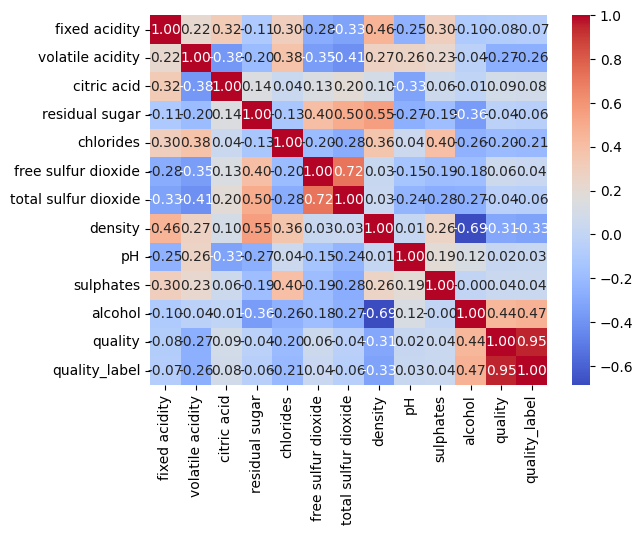

In [97]:
sns.heatmap(corr, fmt=".2f", annot=True, cmap="coolwarm")

In [98]:
correlation = df_all.corr()['quality'].drop(['quality', 'quality_label']).sort_values(ascending=False)
top_features = correlation.abs()

In [99]:
top_features.sort_values(ascending=False)

alcohol                 0.444319
density                 0.305858
volatile acidity        0.265699
chlorides               0.200666
type                    0.119323
citric acid             0.085532
fixed acidity           0.076743
free sulfur dioxide     0.055463
total sulfur dioxide    0.041385
sulphates               0.038485
residual sugar          0.036980
pH                      0.019506
Name: quality, dtype: float64

#### Selection

In [100]:
selected_features = top_features.sort_values(ascending=False).drop('type').head(11).index.tolist()
#selected_features.remove('free sulfur dioxide')
#selected_features.remove('chlorides')
#selected_features.remove('fixed acidity')
#selected_features.remove('citric acid')
print(selected_features)

['alcohol', 'density', 'volatile acidity', 'chlorides', 'citric acid', 'fixed acidity', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'residual sugar', 'pH']


In [101]:
X = df_all.drop(['quality', 'quality_label', 'type'], axis=1)
X_selected_features = df_all[selected_features]
y = df_all['quality_label']

## Train_and_Test split + scaling

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y, 
                                                    test_size=0.2, 
                                                    stratify=y, 
                                                    random_state=42)

### Scaling

In [103]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training model

In [104]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

Evaluation

In [105]:
y_pred = dt.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.63      0.65       477
           1       0.55      0.33      0.42       567
           2       0.41      0.79      0.54       256

    accuracy                           0.53      1300
   macro avg       0.54      0.59      0.53      1300
weighted avg       0.56      0.53      0.52      1300

Confusion Matrix:
 [[302 118  57]
 [138 189 240]
 [ 17  36 203]]
Accuracy: 0.5338461538461539


### Visualize Tree

Text(0.5, 1.0, 'Decision Tree - max_depth=5')

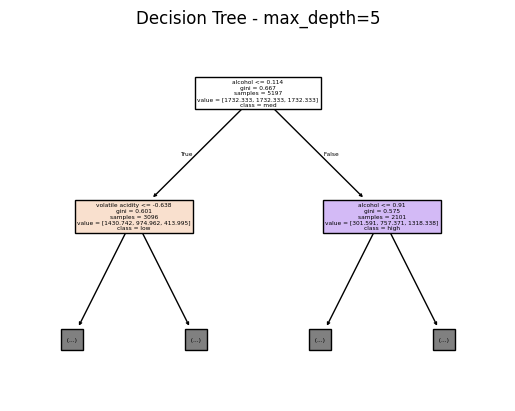

In [106]:
plot_tree(dt, feature_names=X_selected_features.columns, class_names=class_label, filled=True, max_depth=1)
plt.title("Decision Tree - max_depth=5")

## Improvement model

In [107]:
params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [108]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'), 
                    param_grid=params,
                    cv=5,
                    scoring='accuracy',)

In [109]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [110]:
print("Best parameters:", grid.best_params_)
best_tree = grid.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


### New Evaluation (Best)

In [111]:
y_pred_best = best_tree.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Model Accuracy: 0.6453846153846153


Text(0.5, 1.0, 'Decision Tree - GridSearchCV')

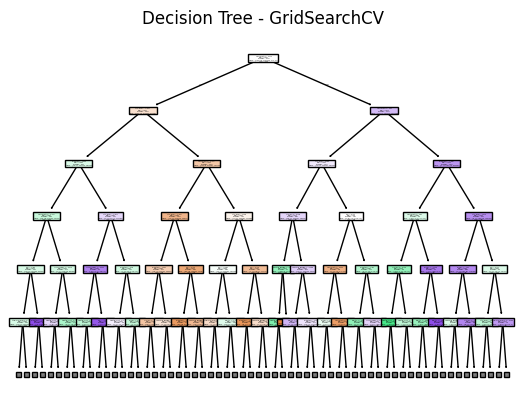

In [112]:
plot_tree(best_tree, max_depth=5,feature_names=X.columns, class_names=class_label, filled=True)
plt.title("Decision Tree - GridSearchCV")

In [113]:
print("Classification Report:\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.69      0.68       477
           1       0.64      0.62      0.63       567
           2       0.60      0.62      0.61       256

    accuracy                           0.65      1300
   macro avg       0.64      0.64      0.64      1300
weighted avg       0.65      0.65      0.65      1300

Confusion Matrix:
 [[329 132  16]
 [127 351  89]
 [ 31  66 159]]
Accuracy: 0.6453846153846153


## Feature Importance on Model

Show the feature importance in the model

In [114]:
importances = pd.Series(best_tree.feature_importances_, index=X_selected_features.columns)
importances = importances.sort_values(ascending=True)

Text(0.5, 1.0, 'Feature Importance - Decision Tree')

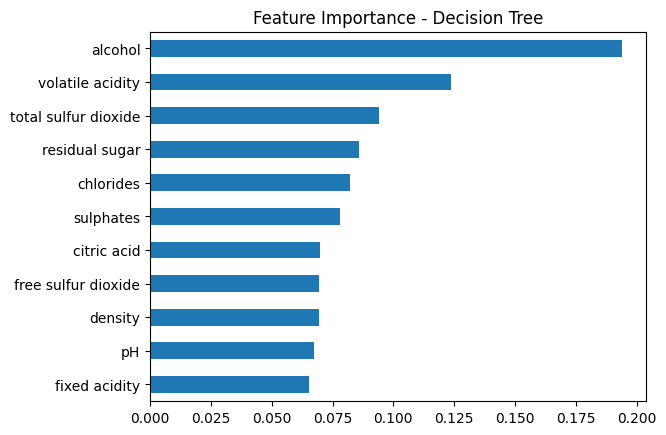

In [115]:
importances.plot(kind='barh')
plt.title("Feature Importance - Decision Tree")

## Text tree

Display the Tree in text-format

In [118]:
from sklearn.tree import export_text

In [119]:
tree_rules = export_text(best_tree, feature_names=list(X.columns), max_depth=4)
print(tree_rules)

|--- fixed acidity <= 0.11
|   |--- citric acid <= -0.64
|   |   |--- sulphates <= 1.50
|   |   |   |--- fixed acidity <= -0.37
|   |   |   |   |--- pH <= 1.96
|   |   |   |   |   |--- truncated branch of depth 14
|   |   |   |   |--- pH >  1.96
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- fixed acidity >  -0.37
|   |   |   |   |--- residual sugar <= -0.47
|   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |--- residual sugar >  -0.47
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |--- sulphates >  1.50
|   |   |   |--- citric acid <= -0.88
|   |   |   |   |--- residual sugar <= -0.22
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- residual sugar >  -0.22
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- citric acid >  -0.88
|   |   |   |   |--- sulphates <= 2.03
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- sulphates >  2.03
|   |   |   |   |   |--- trunc

## ROC e AUC

Display graphs ROC-AUC for binary and multiclass classification

In [120]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [121]:
classes_label_graph = [0, 1, 2]

### Binary

In [85]:
y_proba_dt = best_tree.predict_proba(X_test)[:, 1]

In [86]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)

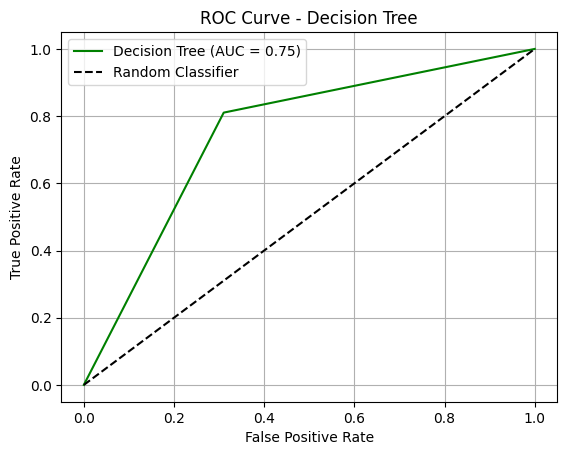

In [87]:
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})', color='green')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.grid()

### Multiclass

In [123]:
# Binarization: multiclass
y_test_bin = label_binarize(y_test, classes=classes_label_graph)
y_score = best_tree.predict_proba(X_test)

# Calculate AUC for any calsses
auc_score = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"Macro-average AUC (OvR): {auc_score:.3f}")

Macro-average AUC (OvR): 0.728


## Precision, Recall

### Binary

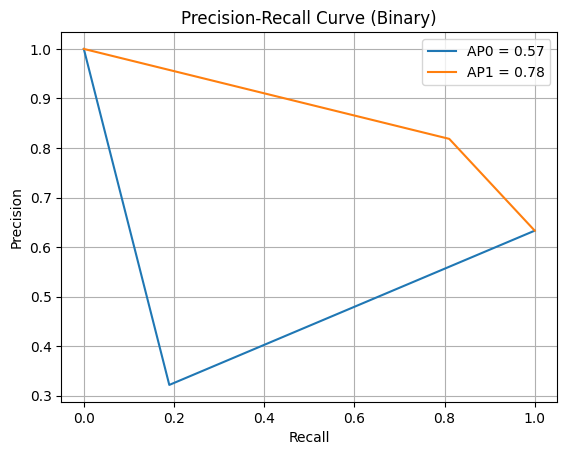

In [88]:
y_proba = best_tree.predict_proba(X_test)[:, 1]
y_proba2 = best_tree.predict_proba(X_test)[:, 0]
# Calculate PR Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

precision2, recall2, thresholds = precision_recall_curve(y_test, y_proba2)
ap2 = average_precision_score(y_test, y_proba2)


# Plot
plt.plot(recall2, precision2, label=f'AP0 = {ap2:.2f}')
plt.plot(recall, precision, label=f'AP1 = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Binary)')
plt.legend()
plt.grid(True)

### Multiclass

In [124]:
y_test_bin = label_binarize(y_test, classes=classes_label_graph)
y_proba = best_tree.predict_proba(X_test)

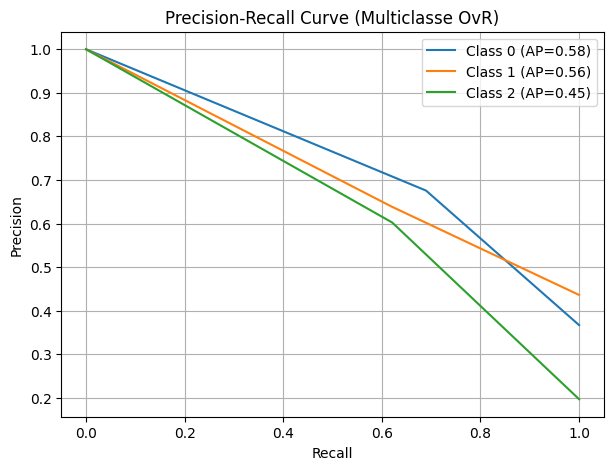

In [125]:
plt.figure(figsize=(7, 5))
for i in range(len(classes_label_graph)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f'Class {classes_label_graph[i]} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclasse OvR)')
plt.legend()
plt.grid(True)